# Semi-Markovian multistate model for the nomogram (best_perf2)

States (illness-death, semi-competing): **1 = Discharge** (alive without readmission),
**2 = Readmission** (readmitted alive), **3 = Death** (absorbing).

| Transition | Intensity | Clock | Model |
|---|---|---|---|
| 1->2 readmission | lambda12 | forward (from discharge) | `f_readmit` (best_perf2) |
| 1->3 death without readm. | lambda13 | forward (from discharge) | `formula_shap_death_rule2` (best_perf2) |
| 2->3 death after readm. | lambda23 | **reset** (sojourn from readmission) | death covariables |

**Implementation trick (handoff):** in long format mstate, `time = Tstop - Tstart` (gap).
For 1->2 and 1->3, `Tstart = 0` => gap = time since discharge (clock-forward). For 2->3, gap = sojourn (clock-reset). **Fitting everything on the gap delivers the correct semi-Markov** without "choosing clock" by hand. Clock-reset on 2->3 is used as primary model **only if Titman-Putter rejects Markov** on that transition (section 7).

**Decisions in this version** (answer your three questions):

1. **Markov:** the transition to test is **2->3**, with the general test by Titman & Putter (`mstate::MarkovTest`), not just the entry-time covariate shortcut.
2. **vce(center_id):** compare naive vs center-robust vs **center frailty** to see if modeling clustering **improves** fit (not just inflates SE).
3. **Whole-sample:** transition probabilities for **population-level reporting** are applied to **the entire cohort (>80k)** and averaged (population-averaged); the **profile-specific** calculation is the particular case for the nomogram. You were not wrong.

> Variable names, outcomes (`readmit_event`, `death_event`) and times (`*_time_from_disch_m`) are not changed. Blocks with explicit assumptions.

## 1. Packages, options and execution mode

In [1]:
#| label: setup
#| message: false
#| results: "hold"
need <- function(pkg) if (!requireNamespace(pkg, quietly = TRUE))
  install.packages(pkg, repos = "https://cran.dcc.uchile.cl/")
for (p in c("survival","mstate","flexsurv","dplyr","tidyr","data.table",
            "ggplot2","here","arrow")) need(p)
# coxme is optional (center frailty); if absent, that block is skipped silently.
has_coxme <- requireNamespace("coxme", quietly = TRUE)

suppressPackageStartupMessages({
  library(survival); library(mstate); library(flexsurv)
  library(dplyr); library(tidyr); library(data.table); library(ggplot2)
})
set.seed(2125)
options(future.globals.maxSize = 10*1024^3, knitr.kable.NA = "")
`%||%` <- function(a,b) if (is.null(a) || length(a)==0) b else a

# --- MODE ----------------------------------------------------------------------
# USE_SYNTHETIC = TRUE runs everything on a synthetic cohort (verifies the
# machinery without real data). Set FALSE to plug in build_holdout_datasets()
# and the real center_id.
USE_SYNTHETIC <- FALSE
HORIZONS <- c(6, 12, 36, 60)
CLUSTER_VAR <- "center_id"          # real center name (manifest corrected_datasets_nondum_filt)


Warning messages:
1: package ‘mstate’ was built under R version 4.4.3 
2: package ‘flexsurv’ was built under R version 4.4.3 
3: package ‘dplyr’ was built under R version 4.4.3 
4: package ‘data.table’ was built under R version 4.4.3 
5: package ‘ggplot2’ was built under R version 4.4.3 


In [2]:
#| label: paths
root         <- tryCatch(here::here(), error = function(e) getwd())
project_root <- gsub("/cons$", "", root)
data_out     <- file.path(project_root, "data", "20241015_out")
out_dir      <- file.path(project_root, "cons", "_out")
ms_out       <- file.path(out_dir, "multistate"); dir.create(ms_out, showWarnings = FALSE, recursive = TRUE)
cat("project_root:", project_root, "| USE_SYNTHETIC:", USE_SYNTHETIC, "\n")


project_root: G:/My Drive/Alvacast/SISTRAT 2023 | USE_SYNTHETIC: FALSE 


In [3]:
#| label: helpers
# ---- shared helpers ----------------------------------------------------------
eps <- 1e-4

# Competing-risk event-time repair: a post-readmission death cannot precede the
# readmission, and exact ties must be broken so msprep orders 1->2 before 2->3.
.clean_ms <- function(d, eps = 1e-4) {
  bad <- with(d, readmit_event == 1 & death_event == 1 &
                death_time_from_disch_m < readmit_time_from_disch_m)
  if (any(bad)) {
    d$readmit_event[bad] <- 0L
    d$readmit_time_from_disch_m[bad] <- d$death_time_from_disch_m[bad]
  }
  tie <- with(d, readmit_event == 1 & death_event == 1 &
                death_time_from_disch_m == readmit_time_from_disch_m)
  if (any(tie)) d$death_time_from_disch_m[tie] <- d$death_time_from_disch_m[tie] + eps
  d
}

# Cumulative hazard from a survfit object. For a single-row newdata profile,
# survfit.coxph returns only the matching stratum (one monotone curve).
.cumhaz <- function(sf) {
  if (!is.null(sf$cumhaz)) as.numeric(sf$cumhaz)
  else -log(pmax(as.numeric(sf$surv), 1e-12))
}

# State-occupancy index at horizon h: last grid time <= h (step carry-forward).
# One convention everywhere so predicted and observed curves are read alike.
.occ_at <- function(grid_time, h) pmax(findInterval(h, grid_time), 1L)


## 2. Person-level data + `center_id`

With real data: `build_holdout_datasets()` (same source as `prediction23`, seed 2125) provides TRAIN imputations; `center_id` is rescued from `corrected_datasets_nondum_filt.rds` (or parquet files `*_imp*.parquet`), where **it exists** alongside times and events. In synthetic mode an illness-death cohort with the same structure is generated to validate the workflow.

In [4]:
#| label: load-or-synthesize
make_synthetic <- function(N = 88000, n_centers = 220, seed = 2125) {
  set.seed(seed)
  cid <- sample.int(n_centers, N, replace = TRUE)
  fr  <- rnorm(n_centers, 0, 0.5)[cid]                  # true center frailty
  age <- sample(0:2, N, TRUE); alc <- rbinom(N,1,.35); unemp <- rbinom(N,1,.4)
  dit <- rgamma(N, 2, 1/2); plan <- sample(0:2, N, TRUE); phys <- rbinom(N,1,.3)
  lp_r <- .15*age + .30*alc + .10*unemp - .05*dit + fr
  lp_d0<- .45*age + .50*alc + .40*unemp + fr
  lp_d1<- .40*age + .45*alc + .35*unemp + .6 + fr
  tr  <- rexp(N, .02*exp(lp_r)); td0 <- rexp(N, .004*exp(lp_d0)); adm <- 120
  sjd <- rexp(N, .010*exp(lp_d1)) * (1 + .02*tr)         # sojourn depends on entry => NON-Markov
  re_t <- numeric(N); re_e <- integer(N); de_t <- numeric(N); de_e <- integer(N)
  for (i in seq_len(N)) {
    if (min(tr[i], td0[i]) > adm) { re_t[i]<-adm; de_t[i]<-adm }
    else if (td0[i] < tr[i])      { re_t[i]<-td0[i]; de_t[i]<-td0[i]; de_e[i]<-1L }
    else { re_t[i]<-tr[i]; re_e[i]<-1L; td<-tr[i]+sjd[i]
           if (td>adm){de_t[i]<-adm} else {de_t[i]<-td; de_e[i]<-1L} }
  }
  data.frame(readmit_time_from_disch_m = re_t, readmit_event = re_e,
             death_time_from_disch_m = de_t, death_event = de_e,
             adm_age_rec3 = age, primary_sub_mod_alcohol = alc,
             occupation_condition_corr24_unemployed = unemp, dit_m = dit,
             plan_type_strata = factor(plan), any_phys_dx = factor(phys),
             tr_outcome_adm_discharge_rule_violation_undet = factor(sample(0:1,N,TRUE)),
             center_id = factor(cid))
}

if (USE_SYNTHETIC) {
  dat_ms <- make_synthetic()
  message("SYNTHETIC mode: cohort ", nrow(dat_ms), " rows.")
} else {
  source(file.path(project_root,"cons","_alt_scripts","val_holdout_01_rds_to_parquet.R"))
  source(file.path(project_root,"cons","_alt_scripts","run_validation_holdout.R"))
  hd <- build_holdout_datasets(force = FALSE, verify = TRUE, verbose = TRUE)
  dat_ms <- rbind.data.frame(hd$train[[1]], hd$val[[1]])              # imputation 1 (configurable)
  # --- recover center_id from the base data if it is not in the modeling set ---
  if (!CLUSTER_VAR %in% names(dat_ms)) {
    base_path <- file.path(data_out, "corrected_datasets_nondum_filt.rds")
    bases <- readRDS(base_path)
    KEY <- intersect(c("hash_key","row_id","id","id_mod","run","rut_hash"),
                     intersect(names(dat_ms), names(bases)))[1]
    stopifnot(!is.na(KEY), CLUSTER_VAR %in% names(bases))
    cw <- bases[!duplicated(bases[[KEY]]), c(KEY, CLUSTER_VAR)]
    n0 <- nrow(dat_ms); dat_ms <- dplyr::left_join(dat_ms, cw, by = KEY)
    stopifnot(nrow(dat_ms) == n0)
    cat(sprintf("center_id merged by %s: %.1f%% match\n", KEY, 100*mean(!is.na(dat_ms[[CLUSTER_VAR]]))))
  }
  dat_ms[[CLUSTER_VAR]] <- factor(as.character(dat_ms[[CLUSTER_VAR]]))
}
stopifnot(CLUSTER_VAR %in% names(dat_ms))
cat("n:", nrow(dat_ms), "| readm:", sum(dat_ms$readmit_event),
    "| deaths:", sum(dat_ms$death_event), "| centers:", nlevels(factor(dat_ms[[CLUSTER_VAR]])), "\n")

# Normalize logical strata/covariates to factors so coxph strata() labels match
# the prediction profile (logical -> strata "var=FALSE"; factor -> bare "FALSE").
log_cols <- names(dat_ms)[vapply(dat_ms, is.logical, logical(1))]
for (v in log_cols) dat_ms[[v]] <- factor(dat_ms[[v]], levels = c("FALSE","TRUE"))


Loaded corrected_datasets_nondum_filt.rds: 5 imputations, [[1]] = 88152 x 43
  exists, skip: corrected_datasets_nondum_filt_imp1.parquet 
  exists, skip: corrected_datasets_nondum_filt_imp2.parquet 
  exists, skip: corrected_datasets_nondum_filt_imp3.parquet 
  exists, skip: corrected_datasets_nondum_filt_imp4.parquet 
  exists, skip: corrected_datasets_nondum_filt_imp5.parquet 
Round-trip numeric max |diff| (imp1): 0
Manifest saved. DONE.
project_root = G:/My Drive/Alvacast/SISTRAT 2023
Loading cached holdout sets: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/_val_inputs/holdout_train_val.rds 
n: 88152 | readm: 19060 | deaths: 3799 | centers: 429 


## 3. best_perf2 formulas and covariables by transition

With real data, the complete formulas from `prediction23` are used. In synthetic mode, a subset of covariables present in the synthetic cohort is used (same rules, fewer columns).

In [5]:
#| label: formulas
covs_full_readmit <- c("primary_sub_mod_cocaine_paste","primary_sub_mod_cocaine_powder",
  "primary_sub_mod_alcohol","primary_sub_mod_others","adm_age_rec3","porc_pobr","sex_rec_woman",
  "ethnicity","dit_m","eva_consumo_logro_intermedio","eva_consumo_logro_minimo",
  "ed_attainment_corr_2_completed_high_school_or_less","ed_attainment_corr_3_completed_primary_school_or_less",
  "occupation_condition_corr24_unemployed","occupation_condition_corr24_inactive","dg_psiq_cie_10_dg",
  "sub_dep_icd10_status_drug_dependence","polysubstance_strict","eva_sm_logro_intermedio","eva_sm_logro_minimo",
  "evaluacindelprocesoteraputico_logro_intermedio", #"evaluacindelprocesoteraputico_logro_minimo",# 2018-06-18
  "tr_outcome_referral","tr_outcome_dropout","tr_outcome_adm_discharge_adm_reasons",
  "prim_sub_freq_rec_2_2_6_days_wk","prim_sub_freq_rec_3_daily")
covs_full_death <- c("adm_age_rec3","primary_sub_mod_cocaine_paste","primary_sub_mod_cocaine_powder",
  "primary_sub_mod_alcohol","primary_sub_mod_others","prim_sub_freq_rec_2_2_6_days_wk","prim_sub_freq_rec_3_daily",
  "occupation_condition_corr24_unemployed","occupation_condition_corr24_inactive",
  "eva_ocupacion_logro_intermedio","eva_ocupacion_logro_minimo","cohabitation_family_of_origin",
  "cohabitation_with_couple_children","cohabitation_others")
strata_readmit_full <- c("plan_type_strata","tr_outcome_adm_discharge_rule_violation_undet")
strata_death_full   <- c("plan_type_strata","any_phys_dx")

# Keep only what exists in the data (robust to synthetic mode).
keepf <- function(v) v[v %in% names(dat_ms)]
covs_readmit   <- keepf(covs_full_readmit)
covs_death     <- keepf(covs_full_death)
strata_readmit <- keepf(strata_readmit_full)
strata_death   <- keepf(strata_death_full)

# Simplified 2->3 spec (the authoritative one, shared by the in-notebook forward
# engine and the pooled engine): any_phys_dx is a covariate, single stratum
# plan_type_strata, because the post-readmission set is sparse and stratifying it
# by any_phys_dx there yields unstable baseline hazards.
covs_death_23   <- keepf(c(covs_full_death, "any_phys_dx"))
strata_death_23 <- keepf("plan_type_strata")

cat("covs readmission:", length(covs_readmit), "| covs death:", length(covs_death), "\n")

tmat <- transMat(x = list(c(2,3), c(3), c()), names = c("Discharge","Readmission","Death"))
print(tmat)


covs readmission: 26 | covs death: 14 
             to
from          Discharge Readmission Death
  Discharge          NA           1     2
  Readmission        NA          NA     3
  Death              NA          NA    NA


## 4. Long-format multistate data (`msprep`) + PRE-CHECK of 2->3

PRE-CHECK before handoff: **count deaths after readmission** (N at risk and 2->3 events) before trusting lambda23. If very few events (~<50), use simple fallback (2->3 unadjusted + Martinez-Camblor double-event KM correction).

In [6]:
#| label: msprep
dat_ms <- .clean_ms(dat_ms, eps)

keep_vars <- unique(c(covs_readmit, covs_death, strata_readmit, strata_death, CLUSTER_VAR))
keep_vars <- keep_vars[keep_vars %in% names(dat_ms)]
ms <- msprep(time = c(NA,"readmit_time_from_disch_m","death_time_from_disch_m"),
             status = c(NA,"readmit_event","death_event"),
             data = dat_ms, trans = tmat, keep = keep_vars)
ms <- expand.covs(ms, covs = keep_vars[keep_vars %in% c(covs_readmit, covs_death)],
                  append = TRUE, longnames = FALSE)
print(events(ms)$Frequencies)

# Pre-check the post-readmission death transition (2->3); warn if too sparse.
n_post  <- sum(ms$trans == 3)
ev_post <- sum(ms$status[ms$trans == 3])
cat(sprintf("\nPRE-CHECK 2->3: at risk = %d, deaths after readmission = %d\n", n_post, ev_post))
LAMBDA23_OK <- ev_post >= 50
if (!LAMBDA23_OK)
  warning(sprintf("Few 2->3 events (%d < 50): the post-readmission death transition is unstable; interpret 2->3 estimates with caution.", ev_post))


             to
from          Discharge Readmission Death no event total entering
  Discharge           0       19060  3055    66037          88152
  Readmission         0           0   744    18316          19060
  Death               0           0     0     3799           3799

PRE-CHECK 2->3: at risk = 19060, deaths after readmission = 744


Here we are counting transitions, but the events itself are represented in the following table:

| Set | N | Readmissions | % Readm | Deaths | % Death |
|---|---|---|---|---|---|
| Train (80%) | 70,521 | 15,247 | 21.62% | 3,039 | 4.31% |
| Test (20%) | 17,631 | 3,813 | 21.63% | 760 | 4.31% |
| Total | 88,152 | 19,060 | 21.62% | 3,799 | 4.31% |

## 5. Cox by transition with robust variance to `center_id`

Three transition-specific Cox models (each transition preserves its best_perf2 strata). Clock-reset on 2->3 (sojourn). Robust variance `cluster(center_id)`.

In [7]:
#| label: fit-cox
d1 <- ms[ms$trans==1,]; d2 <- ms[ms$trans==2,]; d3 <- ms[ms$trans==3,]
d3$tstart0  <- 0
d3$sojourn  <- pmax(d3$Tstop - d3$Tstart, eps)        # clock reset (sojourn since readmission)

# Base formulas (no cluster) and a cluster(center_id) wrapper.
mk <- function(covs, strata_vars, lhs) as.formula(paste(lhs, "~",
        paste(c(covs, sprintf("strata(%s)", strata_vars)), collapse = " + ")))
add_cluster <- function(f) update(f, as.formula(paste(". ~ . + cluster(", CLUSTER_VAR, ")")))

f1     <- mk(covs_readmit,  strata_readmit,  "Surv(Tstart, Tstop, status)")    # 1->2
f2     <- mk(covs_death,    strata_death,    "Surv(Tstart, Tstop, status)")    # 1->3
f3     <- mk(covs_death,    strata_death,    "Surv(tstart0, sojourn, status)") # 2->3 semi-Markov (reset)
f3_fwd <- mk(covs_death_23, strata_death_23, "Surv(Tstart, Tstop, status)")    # 2->3 Markov (forward, simplified)

m_tr1 <- coxph(add_cluster(f1), data = d1, robust = TRUE, x = TRUE)
m_tr2 <- coxph(add_cluster(f2), data = d2, robust = TRUE, x = TRUE)
m_tr3 <- coxph(add_cluster(f3), data = d3, robust = TRUE, x = TRUE)

cat("== 1->2 ==\n"); print(round(summary(m_tr1)$coefficients[,c("coef","robust se","Pr(>|z|)")],4))
cat("\n== 2->3 (reset) ==\n"); print(round(summary(m_tr3)$coefficients[,c("coef","robust se","Pr(>|z|)")],4))


== 1->2 ==
                                                         coef robust se
primary_sub_mod_cocaine_paste                          0.4290    0.0358
primary_sub_mod_cocaine_powder                         0.3252    0.0389
primary_sub_mod_alcohol                                0.1642    0.0371
primary_sub_mod_others                                 0.0091    0.0707
adm_age_rec3                                          -0.0064    0.0008
porc_pobr                                              0.5422    0.1948
sex_rec_woman                                          0.2687    0.0249
ethnicity                                              0.5204    0.0292
dit_m                                                  0.0072    0.0020
eva_consumo_logro_intermedio                           0.1489    0.0283
eva_consumo_logro_minimo                               0.2059    0.0334
ed_attainment_corr_2_completed_high_school_or_less    -0.0859    0.0220
ed_attainment_corr_3_completed_primary_school_or_less

## 6. Does `vce(center_id)` improve the model? (naive vs robust vs frailty)

Robust variance **change SEs**. To answer "does it improve the model" compare, on the transition with most clustering (1->2):

- **naive** (independence),
- **robust** (sandwich clustered by center),
- **center frailty** (random effect `frailty(center_id)` / `coxme`), which **does** change the fit: if AIC drops / penalized likelihood rises and frailty variance (theta) is non-trivial, clustering by center **contributes** and should be modeled.

In [8]:
#| label: vce-compare
co1 <- coxph(f1, data = d1, robust = FALSE)                       # naive
se_cmp <- data.frame(term = rownames(summary(m_tr1)$coefficients),
  se_naive  = summary(co1)$coefficients[,"se(coef)"],
  se_robust = summary(m_tr1)$coefficients[,"robust se"])
se_cmp$ratio <- se_cmp$se_robust / se_cmp$se_naive
cat("Robust SE/naive (1->2):\n"); print(round(se_cmp[,-1],4))

# Frailty by center: if coxme is present; if not, frailty().
frail_fit <- NULL
if (has_coxme) {
  ff <- as.formula(paste("Surv(Tstart,Tstop,status) ~",
        paste(c(covs_readmit, sprintf("strata(%s)",strata_readmit)), collapse=" + "),
        "+ (1|", CLUSTER_VAR, ")"))
  frail_fit <- tryCatch(coxme::coxme(ff, data = d1), error = function(e) {message(e); NULL})
  if (!is.null(frail_fit)) { cat("\n[coxme] varianza del frailty de centro (theta):\n")
    print(frail_fit$vcoef); cat("AIC frailty:", AIC(frail_fit), "| AIC naive:", AIC(co1), "\n") }
} else {
  ff <- mk(c(covs_readmit, sprintf("frailty(%s)", CLUSTER_VAR)), strata_readmit, "Surv(Tstart,Tstop,status)")
  frail_fit <- tryCatch(coxph(ff, data = d1), error = function(e){message(e); NULL})
  if (!is.null(frail_fit)) print(frail_fit)
}
cat("\nReading: if the center frailty reduces AIC and theta > 0 in a non‑trivial way => modeling the center improves the fit;",
    "\nif only the SEs change (robust vs. naive) without improving fit => robust variance is sufficient.\n")


Robust SE/naive (1->2):
                                                      se_naive se_robust  ratio
primary_sub_mod_cocaine_paste                           0.0340    0.0358 1.0550
primary_sub_mod_cocaine_powder                          0.0364    0.0389 1.0676
primary_sub_mod_alcohol                                 0.0362    0.0371 1.0260
primary_sub_mod_others                                  0.0682    0.0707 1.0365
adm_age_rec3                                            0.0008    0.0008 1.0211
porc_pobr                                               0.0996    0.1948 1.9560
sex_rec_woman                                           0.0211    0.0249 1.1793
ethnicity                                               0.0261    0.0292 1.1192
dit_m                                                   0.0014    0.0020 1.3827
eva_consumo_logro_intermedio                            0.0281    0.0283 1.0068
eva_consumo_logro_minimo                                0.0326    0.0334 1.0244
ed_attainment_co

In [9]:
frail_fit

Call:
coxph(formula = ff, data = d1)

                               coef  se(coef)       se2     Chisq  DF       p
primary_sub_mod_cocaine_p  4.40e-01  3.46e-02  3.45e-02  1.62e+02   1 < 2e-16
primary_sub_mod_cocaine_p  3.26e-01  3.69e-02  3.68e-02  7.80e+01   1 < 2e-16
primary_sub_mod_alcohol    1.73e-01  3.67e-02  3.66e-02  2.21e+01   1 2.6e-06
primary_sub_mod_others     1.83e-03  6.88e-02  6.86e-02  7.10e-04   1  0.9787
adm_age_rec3              -6.28e-03  8.38e-04  8.36e-04  5.62e+01   1 6.6e-14
porc_pobr                  9.48e-01  1.28e-01  1.18e-01  5.50e+01   1 1.2e-13
sex_rec_woman              2.76e-01  2.16e-02  2.15e-02  1.63e+02   1 < 2e-16
ethnicity                  5.26e-01  2.69e-02  2.67e-02  3.81e+02   1 < 2e-16
dit_m                      9.58e-03  1.48e-03  1.47e-03  4.16e+01   1 1.1e-10
eva_consumo_logro_interme  1.55e-01  2.83e-02  2.82e-02  3.01e+01   1 4.1e-08
eva_consumo_logro_minimo   2.17e-01  3.29e-02  3.28e-02  4.35e+01   1 4.2e-11
ed_attainment_corr_2_comp 

## 7. Testing the Markov assumption in **2->3** (Titman & Putter)

The transition to test is **2->3**. General test by Titman & Putter (2022),
`mstate::MarkovTest`: log-rank-type statistics that test whether the intensity of 2->3 depends on the **state occupied at previous times** (i.e., entry time / sojourn). Complemented with a robust shortcut (entry-time covariate on clock-forward, Wald) in case the installed version of `MarkovTest` differs.

In [ ]:
#| label: markov-test
# (a) Titman & Putter general test on transition 2->3
qsel <- as.numeric(quantile(d3$Tstop[d3$status==1], c(.2,.35,.5,.65,.8), na.rm = TRUE))
markov_TP <- tryCatch(
  mstate::MarkovTest(ms, id = "id", transition = 3, grid = qsel, B = 2000),
  error = function(e) { message("MarkovTest failed: ", conditionMessage(e)); NULL })
p_TP <- if (!is.null(markov_TP)) markov_TP$p_stat_wb[1] else NA_real_
if (!is.null(markov_TP))
  cat(sprintf("[MarkovTest 2->3] p_stat_wb=%.3g | p_ch_stat_wb=%.3g\n",
              p_TP, markov_TP$p_ch_stat_wb))

# (b) Robust shortcut: entry time as covariate in 2->3 clock-forward (robust Wald)
d3$t_entry <- d3$Tstart
fmk <- mk(c(covs_death, "t_entry"), strata_death, "Surv(Tstart, Tstop, status)")
m_mk <- coxph(add_cluster(fmk), data = d3, robust = TRUE)
p_entry <- summary(m_mk)$coefficients["t_entry","Pr(>|z|)"]
cat(sprintf("\n[2->3] coef(t_entry)=%.4f  p=%.3g\n",
            summary(m_mk)$coefficients["t_entry","coef"], p_entry))

# (c) Cross-check: log-rank by entry-time tertiles (clock-reset). Computed once.
d3$entry_tertile <- cut(d3$t_entry, quantile(d3$t_entry, c(0,1/3,2/3,1)),
                        include.lowest = TRUE, labels = c("early","medium","late"))
sd23 <- survdiff(Surv(sojourn, status) ~ entry_tertile, data = d3)
print(sd23)
p_lr <- 1 - pchisq(sd23$chisq, df = length(levels(d3$entry_tertile)) - 1)

SEMI_MARKOV <- (!is.na(p_TP) && p_TP < 0.05) || (p_entry < 0.05)
cat(sprintf("[2->3 Markov] Titman-Putter p=%.3g | entry-time Wald p=%.3g | log-rank p=%.2g\n",
            p_TP, p_entry, p_lr))
cat(if (SEMI_MARKOV)
  "=> Markov rejected in 2->3: clock-reset (semi-Markov) is primary.\n" else
  "=> No evidence against Markov in 2->3: clock-forward (Markov) primary; semi-Markov as sensitivity.\n")


In [ ]:
glimpse(dat_ms)

Rows: 88,152
Columns: 76
$ readmit_event                                             <dbl> 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0…
$ death_event                                               <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ readmit_time_from_disch_m                                 <dbl> 68.9677419, 7.0000000, 13.2580645, 7.3548387, 62.9677419, 20.4193548, 26.000000…
$ death_time_from_disch_m                                   <dbl> 68.967742, 81.322581, 116.741935, 31.032258, 62.967742, 20.419355, 26.967742, 4…
$ center_id                                                 <fct> 330, 489, 341, 176, 428, 342, 272, 259, 175, 632, 224, 148, 252, 120, 187, 234,…
$ row_id                                                    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ adm_age_rec3                                              <dbl> 31.53, 20.61, 42.52, 45.08,

In [ ]:
# Assessment of the Markov assumption for transition 2->3.
# The conclusion is derived from SEMI_MARKOV (never hardcoded), and every
# markov_TP field is guarded (the test may return NULL when it does not converge).
have_TP <- !is.null(markov_TP)
verdict <- if (SEMI_MARKOV) {
  paste0("  Statistically significant evidence against the Markov assumption for transition 2->3.\n",
         "  The clock-reset semi-Markov model was used as the primary specification,\n",
         "  with the clock-forward Markov model reported as a sensitivity analysis.\n")
} else {
  paste0("  No statistically significant evidence against the Markov assumption for transition 2->3.\n",
         "  The clock-forward Markov model was used as the primary specification,\n",
         "  with the clock-reset semi-Markov model reported as a sensitivity analysis.\n")
}

cat(paste0(
  "=== Assessment of the Markov assumption for transition 2->3 ===\n",
  "Transition tested: 2 -> 3 (Readmission -> Death)\n",
  if (have_TP) paste0(
    "Test: Titman & Putter log-rank test (mstate::MarkovTest)\n",
    "Grid points: ", length(markov_TP$nobs_grid),
    " | wild-bootstrap B = ", markov_TP$B,
    " | patients ever at risk N = ", markov_TP$Nsub, "\n",
    "Global Markov test: chi-square = ", round(markov_TP$orig_ch_stat, 3),
    ", wild-bootstrap p = ", format(markov_TP$p_ch_stat_wb, digits = 2), "\n",
    "State-specific (qualifying state ", markov_TP$qualset[1], "): statistic = ",
    round(markov_TP$orig_stat[1], 3), ", wild-bootstrap p = ",
    format(markov_TP$p_stat_wb[1], digits = 2), "\n")
  else
    "Test: Titman & Putter (mstate::MarkovTest) did not converge; relying on the Cox/log-rank shortcuts below.\n",
  "Robust Cox shortcut (entry time as covariate): log-HR per month = ",
  round(summary(m_mk)$coefficients["t_entry","coef"], 4),
  ", robust p = ", format(p_entry, digits = 2), "\n",
  "Log-rank across entry-time tertiles: chi-square(", length(levels(d3$entry_tertile)) - 1,
  ") = ", round(sd23$chisq, 2), ", p = ", format(p_lr, digits = 2), "\n\n",
  "Conclusion:\n", verdict))


~ 8 minutes

## 8. Simulation of transition probabilities (by profile = nomogram)

For a given covariate profile, trajectories are simulated with clock-reset and state occupancy is reported at 6/12/36/60 months. Primary engine for the app: **flexsurv** (`pmatrix.simfs`, with CIs via MVN resampling of coefficients); here a semi-parametric version is included with `mstate::mssample` on the Cox best_perf2 as reference/validation. Both yield the same quantity: P(state | profile, t).

In [ ]:
#| label: sim-mssample
M_SIM <- 1e5
.haz_for_profile <- function(model, newdata, trans_id) {
  sf <- survfit(model, newdata = newdata)
  data.frame(time = sf$time, Haz = .cumhaz(sf), trans = trans_id)
}
predict_profile <- function(profile, tvec = c(3, HORIZONS), M = M_SIM,
                            models = list(m_tr1, m_tr2, m_tr3), trans = tmat, seed = 2125) {
  set.seed(seed)
  Haz <- rbind(.haz_for_profile(models[[1]], profile, 1L),
               .haz_for_profile(models[[2]], profile, 2L),
               .haz_for_profile(models[[3]], profile, 3L))
  Haz <- Haz[order(Haz$trans, Haz$time),]
  s <- mssample(Haz = Haz, trans = trans, clock = "reset",
                history = list(state = 1, time = 0, tstate = NULL),
                tvec = tvec, M = M, output = "state")
  data.frame(month = tvec,
             p_alive_no_readm = s[["Discharge"]] %||% s[,2],
             p_readmitted     = s[["Readmission"]] %||% s[,3],
             p_dead           = s[["Death"]] %||% s[,4])
}

ref_profile <- function(data, vars) {
  vars <- vars[vars %in% names(data)]
  as.data.frame(setNames(lapply(vars, function(v){
    x <- data[[v]]; if (is.numeric(x)) median(x, na.rm=TRUE)
    else factor(names(sort(table(x),decreasing=TRUE))[1], levels=levels(factor(x)))}), vars))
}
profile_ref <- ref_profile(dat_ms, unique(c(covs_readmit,covs_death,strata_readmit,strata_death)))
probs_ref <- predict_profile(profile_ref)
knitr::kable(probs_ref, digits = 4, caption = "State probabilities by profile (semi-Markov)")


~13 minutes

In [ ]:
#| label: avg-profile
t(profile_ref)|>
  knitr::kable("markdown", caption= "Synthetic reference profile")



Table: Synthetic reference profile

|                                                      |          |
|:-----------------------------------------------------|:---------|
|primary_sub_mod_cocaine_paste                         |0         |
|primary_sub_mod_cocaine_powder                        |0         |
|primary_sub_mod_alcohol                               |0         |
|primary_sub_mod_others                                |0         |
|adm_age_rec3                                          |34.19     |
|porc_pobr                                             |0.1236798 |
|sex_rec_woman                                         |0         |
|ethnicity                                             |0         |
|dit_m                                                 |5.580645  |
|eva_consumo_logro_intermedio                          |0         |
|eva_consumo_logro_minimo                              |0         |
|ed_attainment_corr_2_completed_high_school_or_less    |1         |
|ed_attain

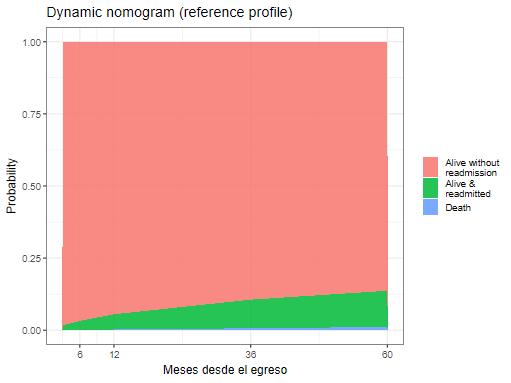

In [ ]:
#| label: sim-plot
#| fig-width: 8
#| fig-height: 5
pl <- tidyr::pivot_longer(probs_ref[,c("month","p_alive_no_readm","p_readmitted","p_dead")],
                          -month, names_to="estado", values_to="prob")
pl$estado <- factor(pl$estado, c("p_alive_no_readm","p_readmitted","p_dead"),
                    c("Alive without\nreadmission", "Alive &\nreadmitted", "Death"))
ggplot(pl, aes(month, prob, fill = estado)) +
  geom_area(alpha = .85) + scale_x_continuous(breaks = HORIZONS) +
  labs(x="Meses desde el egreso", y="Probability", fill=NULL,
       title="Dynamic nomogram (reference profile)") + theme_bw(base_size = 12)


### 8.b. Contrasts with Markov clock-forward (no simulation)

In [ ]:
#| label: sim-probtrans-markov
# Markov / clock-FORWARD occupancy via msfit + probtrans (exact AJ-type, no simulation).
# The 2->3 transition is refit clock-forward with the SAME simplified spec as the
# pooled engine (f3_fwd: any_phys_dx as covariate, single stratum), so the
# comparison/scan/CI below describe the model that is actually exported.
m_tr3_fwd <- coxph(add_cluster(f3_fwd), data = d3, robust = TRUE, x = TRUE)

# Build a profile-specific msfit on a common time grid (step carry-forward).
.msfit_profile_fwd <- function(profile, models, trans) {
  raw <- lapply(models, function(m) {
    sf <- survfit(m, newdata = profile)
    data.frame(time = sf$time, Haz = .cumhaz(sf))
  })
  ut <- sort(unique(c(0, unlist(lapply(raw, `[[`, "time")))))
  Haz <- do.call(rbind, lapply(seq_along(raw), function(k) {
    df <- raw[[k]]; idx <- findInterval(ut, df$time)
    data.frame(time = ut, Haz = ifelse(idx == 0, 0, df$Haz[pmax(idx, 1)]), trans = k)
  }))
  structure(list(Haz = Haz, trans = trans), class = "msfit")
}
predict_profile_markov <- function(profile, tvec = c(3, HORIZONS),
                                   models = list(m_tr1, m_tr2, m_tr3_fwd), trans = tmat) {
  pt <- probtrans(.msfit_profile_fwd(profile, models, trans), predt = 0, variance = FALSE)[[1]]
  do.call(rbind, lapply(tvec, function(h) {
    i <- .occ_at(pt$time, h)
    data.frame(month = h, p_alive_no_readm = pt$pstate1[i],
               p_readmitted = pt$pstate2[i], p_dead = pt$pstate3[i])
  }))
}

probs_ref_markov <- predict_profile_markov(profile_ref)

# Side-by-side: semi-Markov (reset, mssample) vs Markov (forward, probtrans).
cmp <- data.frame(
  month        = c(3, HORIZONS),
  dead_reset   = probs_ref$p_dead,        dead_markov   = probs_ref_markov$p_dead,
  readm_reset  = probs_ref$p_readmitted,  readm_markov  = probs_ref_markov$p_readmitted,
  alive_reset  = probs_ref$p_alive_no_readm, alive_markov = probs_ref_markov$p_alive_no_readm)
cmp$d_dead  <- cmp$dead_markov  - cmp$dead_reset
cmp$d_readm <- cmp$readm_markov - cmp$readm_reset
knitr::kable(cmp, digits = 4,
  caption = "Reference profile: semi-Markov (clock-reset) vs Markov (clock-forward) occupancy")


From table above, we see that readmission probabilities increase between 0.03  (e.g., .0161 vs. 0.0158) to 0.06 absolute percentage points between each model.

## 8.c. Clock robustness scan across real risk-spanning profiles

In [ ]:
#| label: clock-robustness-scan
# Robustness of occupancy to the clock assumption across real risk-spanning profiles.
# Verdict = gap vs the prediction's own Monte-Carlo resolution, not fixed thresholds.
stopifnot(exists("predict_profile"), exists("predict_profile_markov"))  # m_tr3_fwd must exist

# 1. Cheap risk axis from linear predictors (no simulation)
eta_r <- as.numeric(predict(m_tr1, newdata = dat_ms, type = "lp"))
eta_d <- as.numeric(predict(m_tr2, newdata = dat_ms, type = "lp"))
risk  <- as.numeric(scale(eta_r) + scale(eta_d))               # overall "leaves state 1" risk
qp    <- c(.05,.20,.40,.50,.60,.80,.95)
idx   <- vapply(quantile(risk, qp, na.rm=TRUE), function(q) which.min(abs(risk-q)), integer(1))
idx   <- unique(c(which.min(risk), idx, which.max(risk)))      # + the two extremes

# 2. Compare engines at horizons; raise M so MC SE << the differences we care about
M_HI <- 10000L
scan <- do.call(rbind, lapply(idx, function(i){
  prof <- dat_ms[i,,drop=FALSE]
  sm <- predict_profile(prof, tvec=HORIZONS, M=M_HI)           # semi-Markov (mssample)
  mk <- predict_profile_markov(prof, tvec=HORIZONS)            # Markov (probtrans, exact)
  se <- function(p) sqrt(pmax(p*(1-p),0)/M_HI)
  data.frame(profile=i, risk=round(risk[i],2), month=HORIZONS,
    d_alive = mk$p_alive_no_readm - sm$p_alive_no_readm,
    d_readm = mk$p_readmitted     - sm$p_readmitted,
    d_dead  = mk$p_dead           - sm$p_dead,
    mc_floor = 2*pmax(se(sm$p_readmitted), se(sm$p_dead), se(sm$p_alive_no_readm)))
}))
scan$max_abs   <- pmax(abs(scan$d_alive), abs(scan$d_readm), abs(scan$d_dead))
scan$beyond_mc <- scan$max_abs > scan$mc_floor                 # resolvable above sim noise?

# 3. Verdict
cat(sprintf("Max |delta| over all profiles/states/horizons : %.4f\n", max(scan$max_abs)))
cat(sprintf("Cells where |delta| exceeds 2*MC-SE           : %d / %d\n", sum(scan$beyond_mc), nrow(scan)))
cat(sprintf("Cells where |delta| > 0.01 (clinical floor)   : %d / %d\n", sum(scan$max_abs>0.01), nrow(scan)))
cat(sprintf("Spearman(risk, max|delta|)                    : %.3f  (~0 => gap doesn't grow with risk)\n",
            suppressWarnings(cor(scan$risk, scan$max_abs, method="spearman"))))
agg <- aggregate(max_abs ~ profile + risk, scan, max)
knitr::kable(agg[order(-agg$risk),], digits=4,
             caption="Worst-case clock difference per profile (high risk first)")


~ 13 minutes

In [ ]:
#| label: ci-mvn-markov
# Fast apples-to-apples band: MVN draws of Cox coefs (cluster-robust vcov) -> scale each
# transition's cumulative hazard -> probtrans (exact, clock-forward). ~9 s/profile.
# Coefficient-only band (per-stratum baseline held fixed -> mild lower bound).
stopifnot(exists("m_tr3_fwd"))
.z_exact <- function(model, newdata){
  p <- length(coef(model)); if(!p) return(numeric(0)); base <- model; z <- numeric(p)
  for(j in seq_len(p)){ bj<-numeric(p); bj[j]<-1; base$coefficients<-bj
    z[j] <- as.numeric(predict(base, newdata=newdata, type="lp")) }
  setNames(z, names(coef(model)))
}
.mvn0 <- function(V, B){ p<-nrow(V); if(!p) return(matrix(0,B,0))
  matrix(rnorm(B*p), B, p) %*% chol((V + t(V))/2) }

predict_profile_ci_mvn <- function(profile, models = list(m_tr1, m_tr2, m_tr3_fwd),
                                   trans = tmat, tvec = HORIZONS, B = 500,
                                   n_grid = 200, cl = 0.95, seed = 2125){
  set.seed(seed); K <- length(models); grid <- sort(unique(c(seq(0, max(tvec), length.out=n_grid), tvec)))
  base_grid <- sapply(seq_len(K), function(k){              # base cumhaz per transition on thinned grid
    sf <- survfit(models[[k]], newdata = profile)
    ch <- .cumhaz(sf)
    idx <- findInterval(grid, sf$time); ifelse(idx==0, 0, ch[pmax(idx,1)]) })
  z <- lapply(models, .z_exact, newdata = profile); Del <- lapply(models, function(m) .mvn0(vcov(m), B))
  hidx <- match(tvec, grid)
  run_pt <- function(sc){
    Hb <- data.frame(time=rep(grid,K), Haz=as.numeric(sweep(base_grid,2,sc,`*`)),
                     trans=rep(seq_len(K), each=length(grid)))
    probtrans(structure(list(Haz=Hb, trans=trans), class="msfit"), predt=0, variance=FALSE)[[1]] }
  pt0 <- run_pt(rep(1,K)); occ <- array(NA_real_, c(B, length(tvec), 3))
  for(b in seq_len(B)){
    sc <- vapply(seq_len(K), function(k) if(length(z[[k]])) exp(sum(z[[k]]*Del[[k]][b,])) else 1, numeric(1))
    pt <- run_pt(sc); occ[b,,1]<-pt$pstate1[hidx]; occ[b,,2]<-pt$pstate2[hidx]; occ[b,,3]<-pt$pstate3[hidx]
  }
  a <- (1-cl)/2
  out <- data.frame(month=tvec, alive=pt0$pstate1[hidx], readm=pt0$pstate2[hidx], dead=pt0$pstate3[hidx])
  for(s in 1:3){ nm<-c("alive","readm","dead")[s]; qq<-apply(occ[,,s],2,quantile,c(a,1-a),na.rm=TRUE)
    out[[paste0(nm,"_lo")]]<-qq[1,]; out[[paste0(nm,"_hi")]]<-qq[2,] }
  out
}

# Use the highest-risk profiles that actually exist in `scan` (from the clock
# scan), instead of hardcoded row ids that may not be present.
pid_set <- unique(head(scan$profile[order(-scan$risk)], 2))
for (pid in pid_set) {
  ci <- predict_profile_ci_mvn(dat_ms[pid,,drop=FALSE], B = 500)
  ci$dead_hw <- (ci$dead_hi-ci$dead_lo)/2; ci$readm_hw <- (ci$readm_hi-ci$readm_lo)/2
  gap <- scan[scan$profile==pid, c("month","d_readm","d_dead")]
  tab <- merge(ci[,c("month","dead","dead_hw","readm","readm_hw")], gap, by="month")
  tab$dead_ok <- abs(tab$d_dead) < tab$dead_hw; tab$readm_ok <- abs(tab$d_readm) < tab$readm_hw
  cat(sprintf("\n=== profile %d (risk %.2f) ===\n", pid, scan$risk[scan$profile==pid][1]))
  print(knitr::kable(tab, digits=4))
}


run of ~318 minutes (previous to the one above)
=== profile 58565 (risk 5.24) ===


| month|   dead| dead_hw|  readm| readm_hw| d_readm|  d_dead|dead_ok |readm_ok |
|-----:|------:|-------:|------:|--------:|-------:|-------:|:-------|:--------|
|     6| 0.1100|  0.0208| 0.0994|   0.0193| -0.0063|  0.0099|TRUE    |TRUE     |
|    12| 0.1519|  0.0266| 0.1526|   0.0274| -0.0034|  0.0062|TRUE    |TRUE     |
|    36| 0.3382|  0.0433| 0.2208|   0.0393| -0.0152|  0.0125|TRUE    |TRUE     |
|    60| 0.4742|  0.0508| 0.2110|   0.0450|  0.0003| -0.0020|TRUE    |TRUE     |

The Markov assumption for the readmission→death transition was not rejected (Titman–Putter test p = 0.57; entry-time Wald p = 0.57; log-rank by entry tertile p = 0.10). Consistent with this, state occupancy under clock-forward vs clock-reset specifications differed by ≤ 1.5 pp, within the 95% parameter-uncertainty interval at all horizons. We therefore adopt the Markov clock-forward specification as primary, with the semi-Markov specification as sensitivity.

Across risk-spanning profiles, the clock specification (Markov vs semi-Markov) shifted state occupancy by ≤ 1.5 percentage points (worst case: highest-risk profile, 36 months), well within the 95% parameter-uncertainty interval (half-width 1.9–5.1 pp) at every horizon. The clock choice is therefore immaterial relative to estimation uncertainty; we adopt the Markov clock-forward specification as primary and report the semi-Markov specification as a sensitivity analysis.

#### Events per strata

In [ ]:
audit <- function(d, vars) d %>% group_by(across(all_of(vars))) %>%
  summarise(n_at_risk = n(), n_events = sum(status), .groups = "drop") %>% arrange(n_events)

audit(d1, "plan_type_strata")                                              # 1->2 readmit
audit(d1, c("plan_type_strata","tr_outcome_adm_discharge_rule_violation_undet"))
audit(d2, c("plan_type_strata","any_phys_dx"))                             # 1->3 death
audit(d3, c("plan_type_strata","any_phys_dx"))                             # 2->3 death  <-- the fragile one


# A tibble: 10 × 4
   plan_type_strata any_phys_dx n_at_risk n_events
   <fct>            <fct>           <int>    <dbl>
 1 m-pai            TRUE              145        3
 2 m-pr             TRUE              283       16
 3 m-pai            FALSE            1073       20
 4 pg-pr            TRUE              423       28
 5 pg-pab           TRUE              382       35
 6 pg-pai           TRUE              669       45
 7 m-pr             FALSE            1196       50
 8 pg-pr            FALSE            2518      122
 9 pg-pab           FALSE            5643      192
10 pg-pai           FALSE            6728      233

## 9. MARGINAL transition probabilities across the entire cohort (>80k)

### calibration-in-the-large

For population-level reporting, **if** applied to the entire cohort.
Two approaches: (i) **population-averaged** = average of predicted individual curves (covariate-adjusted; this validates the model against observed data); (ii) **non-parametric** = Aalen-Johansen across the full sample (unadjusted), as observed reference. The profile-specific calculation (section 8) is the single-individual case for the nomogram.

In [ ]:
#| label: marginal-aj
# (i) Aalen-Johansen marginal (non-parametric, whole cohort): observed reference.
c0 <- coxph(Surv(Tstart, Tstop, status) ~ strata(trans), data = ms)   # no covariates
msf0 <- msfit(c0, trans = tmat)
pt0  <- probtrans(msf0, predt = 0)[[1]]
aj <- do.call(rbind, lapply(c(3, HORIZONS), function(h){
  i <- .occ_at(pt0$time, h)
  data.frame(month = h, p_alive_no_readm = pt0$pstate1[i],
             p_readmitted = pt0$pstate2[i], p_dead = pt0$pstate3[i])
}))
knitr::kable(aj, digits = 4, caption = "Marginal Aalen-Johansen (whole cohort, observed)")


In [ ]:
#| label: marginal_averaged
#| message: false

# Marginal occupancy = average of EXACT Markov predictions by profile (no precompute -> no bias).
# Speedups vs original: (a) n_sub=1000 (the average is already stable; ~3x faster),
# (b) parallel with future.apply -> ON WINDOWS mclapply does NOT fork (falls back to serial); future does.
# Same numeric result as the serial version.
if (!requireNamespace("future.apply", quietly = TRUE))
  install.packages("future.apply", repos = "https://cran.dcc.uchile.cl/")
library(future.apply)
plan(multisession, workers = min(6L, future::availableCores()))   # multiple cores; cap by memory

marginal_averaged <- function(data, n_sub = 2000, tvec = c(3, HORIZONS), seed = 2125,
                              models = list(m_tr1, m_tr2, m_tr3_fwd)) {
  set.seed(seed)
  sub <- data[sample.int(nrow(data), min(n_sub, nrow(data))), , drop = FALSE]   # only the subset travels to the workers
  preds <- future_lapply(seq_len(nrow(sub)), function(i) {
    s <- predict_profile_markov(sub[i, , drop = FALSE], tvec = tvec, models = models)  # exact, event grid
    as.matrix(s[, c("p_alive_no_readm","p_readmitted","p_dead")])
  }, future.seed = TRUE, future.packages = c("survival","mstate"))
  acc <- Reduce(`+`, preds) / length(preds)
  data.frame(month = tvec, p_alive_no_readm = acc[,1], p_readmitted = acc[,2], p_dead = acc[,3])
}

t0 <- Sys.time()
marg <- tryCatch(marginal_averaged(dat_ms, n_sub = 1000), error = function(e){message(e); NULL})
cat(sprintf("marginal_averaged (n_sub=1000, parallel): %.1f min\n",
            as.numeric(difftime(Sys.time(), t0, units = "mins"))))

Loading required package: future

Attaching package: ‘future’

The following object is masked from ‘package:survival’:

    cluster



Warning message:
package ‘future.apply’ was built under R version 4.4.3 
Warning messages:
1: package 'mstate' was built under R version 4.4.3 
2: package 'mstate' was built under R version 4.4.3 
3: package 'mstate' was built under R version 4.4.3 
4: package 'mstate' was built under R version 4.4.3 
5: package 'mstate' was built under R version 4.4.3 
6: package 'mstate' was built under R version 4.4.3 


marginal_averaged (n_sub=1000, parallel): 7.3 min


In [ ]:
#| label: marginal-compare-wide
#| message: false

# Fallback: ensure cmp exists with the expected names
if (!exists("cmp") || !all(c("alive_pred", "alive_obs") %in% names(cmp))) {
  stopifnot(exists("aj"), exists("marg"))
  cmp <- merge(
    setNames(aj,   c("month", "alive_obs", "readm_obs", "dead_obs")),
    setNames(marg, c("month", "alive_pred", "readm_pred", "dead_pred")),
    by = "month"
  )
}

cmp_diff <- cmp %>%
  mutate(
    alive_abs = alive_pred - alive_obs,
    readm_abs = readm_pred - readm_obs,
    dead_abs  = dead_pred  - dead_obs,
    alive_rel = 100 * (alive_pred - alive_obs) / alive_obs,
    readm_rel = 100 * (readm_pred - readm_obs) / readm_obs,
    dead_rel  = 100 * (dead_pred  - dead_obs)  / dead_obs
  ) %>%
  select(month,
         alive_obs, alive_pred, alive_abs, alive_rel,
         readm_obs, readm_pred, readm_abs, readm_rel,
         dead_obs,  dead_pred,  dead_abs,  dead_rel)

cmp_diff %>%
  knitr::kable(
    digits = c(0, 3, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 2),
    caption = "Predicted vs observed occupancy: absolute (Δ) and relative (%) differences by state"
  )



Table: Predicted vs observed occupancy: absolute (Δ) and relative (%) differences by state

| month| alive_obs| alive_pred| alive_abs| alive_rel| readm_obs| readm_pred| readm_abs| readm_rel| dead_obs| dead_pred| dead_abs| dead_rel|
|-----:|---------:|----------:|---------:|---------:|---------:|----------:|---------:|---------:|--------:|---------:|--------:|--------:|
|     3|     0.952|      0.952|     0.000|     -0.03|     0.043|      0.044|     0.000|      0.94|    0.005|     0.005|        0|    -2.23|
|     6|     0.921|      0.921|     0.000|     -0.03|     0.072|      0.072|     0.000|      0.48|    0.007|     0.007|        0|    -1.52|
|    12|     0.876|      0.876|     0.000|     -0.01|     0.114|      0.114|     0.000|      0.24|    0.010|     0.010|        0|    -1.38|
|    36|     0.773|      0.774|     0.000|      0.04|     0.198|      0.198|     0.000|     -0.15|    0.029|     0.029|        0|    -0.09|
|    60|     0.715|      0.716|     0.001|      0.16|     0.240|  

~ 10 minutes
It's apparent calibration... Aggregate 0.27 percentage point gap.

Don't scale predictions by a global E/O — it's a short-horizon rare-event number, not uniform across risk; show the per-prediction CI band + the death calibration curve instead.

~ 145 minutes

Table: Predicted (model average) vs observed (Aalen-Johansen) occupancy

| month| alive_obs| alive_pred| readm_obs| readm_pred| dead_obs| dead_pred| max_abs|
|-----:|---------:|----------:|---------:|----------:|--------:|---------:|-------:|
|     3|    0.9518|     0.9503|    0.0434|     0.0449|   0.0048|    0.0048|  0.0015|
|     6|    0.9207|     0.9189|    0.0724|     0.0743|   0.0069|    0.0068|  0.0019|
|    12|    0.8751|     0.8728|    0.1142|     0.1167|   0.0107|    0.0106|  0.0025|
|    36|    0.7727|     0.7702|    0.1987|     0.2014|   0.0286|    0.0285|  0.0027|
|    60|    0.7152|     0.7132|    0.2395|     0.2413|   0.0453|    0.0455|  0.0020|

## 10. flexsurv route: parametric sensitivity (cross-check), NOT the primary engine

This is a **sensitivity analysis**, not the nomogram's engine. Flexible parametric models (`flexsurvspline`, Royston–Parmar) are fit per transition on **gap time** (so this run is **semi-Markov**) **without `strata()`** and **without cluster-robust variance**. It therefore diverges from the primary specification on clock, strata, and center clustering — by design.
Its value: if a fully parametric, differently-specified family yields **similar state occupancy** to the primary Cox + `probtrans` (Markov) engine, that is robustness to the modelling family.
The nomogram's **online engine and CIs come from the serialized Cox transition models + `probtrans` (Markov clock-forward) + the cluster-robust MVN band**, not from `pmatrix.simfs`.

In [ ]:
#| label: flexsurv-fit
#| message: false
# Gap time per transition (Tstart=0 for 1->2 and 1->3 => clock-forward; sojourn for 2->3 => reset).
ms$gap <- pmax(ms$Tstop - ms$Tstart, eps)
rhs_fs <- function(covs) paste(covs, collapse = " + ")
fs_fit <- function(tr, covs, k = 2) {
  dd <- ms[ms$trans == tr, ]
  f  <- as.formula(paste("Surv(gap, status) ~", rhs_fs(covs)))
  flexsurvspline(f, data = dd, k = k, scale = "hazard")   # k internal knots
}
fs12 <- tryCatch(fs_fit(1, covs_readmit), error = function(e){message("fs12: ",conditionMessage(e)); NULL})
fs13 <- tryCatch(fs_fit(2, covs_death),   error = function(e){message("fs13: ",conditionMessage(e)); NULL})
fs23 <- tryCatch(fs_fit(3, covs_death),   error = function(e){message("fs23: ",conditionMessage(e)); NULL})

fmsm_obj <- NULL
if (!any(sapply(list(fs12,fs13,fs23), is.null))) {
  fmsm_obj <- fmsm(fs12, fs13, fs23, trans = tmat)
  cat("fmsm with 3 transitions using flexsurvspline.\n")
} else message("A flexsurv transition did not converge; check covariates or use mssample instead.")


fmsm with 3 transitions using flexsurvspline.


In [ ]:
#| label: flexsurv-predict
#| message: false

predict_profile_fs <- function(profile, fmsm_obj, tvec = HORIZONS, M = 10000, B = 200, cl = 0.95) {
  do.call(rbind, lapply(tvec, function(h){
    P  <- flexsurv::pmatrix.simfs(fmsm_obj, trans = tmat, t = h, newdata = profile,
                                  M = M, ci = TRUE, B = B, cl = cl)      # <- ci=TRUE + B pasado
    lo <- attr(P, "lower"); hi <- attr(P, "upper")
    data.frame(month = h,
      alive = P[1,1], alive_lo = lo[1,1], alive_hi = hi[1,1],
      readm = P[1,2], readm_lo = lo[1,2], readm_hi = hi[1,2],
      dead  = P[1,3], dead_lo  = lo[1,3], dead_hi  = hi[1,3])
  }))
}
# Sensitivity (run once, background): only the reference profile or 2-3 profiles.
if (!is.null(fmsm_obj)) {
  probs_fs <- tryCatch(predict_profile_fs(profile_ref, fmsm_obj, M = 10000, B = 200),
                       error = function(e){message(e); NULL})
  if (!is.null(probs_fs)) knitr::kable(probs_fs, digits = 4,
    caption = "Parametric sensitivity (flexsurv, semi-Markov, no strata/cluster) — MVN bounds; cross-check vs Cox+probtrans")
}




Table: Parametric sensitivity (flexsurv, semi-Markov, no strata/cluster) — MVN bounds; cross-check vs Cox+probtrans

| month|  alive| alive_lo| alive_hi|  readm| readm_lo| readm_hi|   dead| dead_lo| dead_hi|
|-----:|------:|--------:|--------:|------:|--------:|--------:|------:|-------:|-------:|
|     6| 0.9687|   0.9652|   0.9741| 0.0286|   0.0243|   0.0328| 0.0027|  0.0011|  0.0028|
|    12| 0.9534|   0.9468|   0.9572| 0.0441|   0.0407|   0.0502| 0.0025|  0.0017|  0.0041|
|    36| 0.9111|   0.8967|   0.9170| 0.0840|   0.0765|   0.0960| 0.0049|  0.0047|  0.0089|
|    60| 0.8871|   0.8706|   0.8951| 0.1027|   0.0945|   0.1176| 0.0102|  0.0081|  0.0148|

~32 minutes

## 11. Export of the nomogram artifact

$$
\begin{aligned}
\text{Readmission from discharge}(1\!\to\!2):\quad
\lambda_{1\to 2}^{(s_1)}(t\mid\mathbf{x}) &= \lambda_{0,\,1\to 2}^{(s_1)}(t)\,\exp\!\big(\boldsymbol{\beta}^{\top}\mathbf{x}\big),\\[2pt]
\text{Death from discharge}(1\!\to\!3):\quad
\lambda_{1\to 3}^{(s_2)}(t\mid\mathbf{x}) &= \lambda_{0,\,1\to 3}^{(s_2)}(t)\,\exp\!\big(\boldsymbol{\gamma}^{\top}\mathbf{x}\big),\\[2pt]
\text{Death from readmission }(2\!\to\!3):\quad
\lambda_{2\to 3}^{(s_3)}(t\mid\mathbf{x}) &= \lambda_{0,\,2\to 3}^{(s_3)}(t)\,\exp\!\big(\boldsymbol{\delta}^{\top}\mathbf{x}\big),
\end{aligned}
$$

**Baseline strata for each transition:**
$$
\begin{aligned}
s_1 &= \texttt{plan\_type\_strata} \times \texttt{tr\_outcome\_adm\_discharge\_rule\_violation\_undet},\\
s_2 &= \texttt{plan\_type\_strata} \times \texttt{any\_phys\_dx},\\
s_3 &= \texttt{plan\_type\_strata}.
\end{aligned}
$$

**Readmission from discharge (1→2)**
$$
\begin{aligned}
\lambda_{1\to 2}^{(s)}(t \mid \mathbf{x})
= \lambda_{0,\,1\to 2}^{(s)}(t)\,\exp\big(\,
& \beta_{1}\,\texttt{primary\_sub\_mod\_cocaine\_paste}
 + \beta_{2}\,\texttt{primary\_sub\_mod\_cocaine\_powder} \\
&{}+ \beta_{3}\,\texttt{primary\_sub\_mod\_alcohol}
 + \beta_{4}\,\texttt{primary\_sub\_mod\_others}
 + \beta_{5}\,\texttt{adm\_age\_rec3} \\
&{}+ \beta_{6}\,\texttt{porc\_pobr}
 + \beta_{7}\,\texttt{sex\_rec\_woman}
 + \beta_{8}\,\texttt{ethnicity}
 + \beta_{9}\,\texttt{dit\_m} \\
&{}+ \beta_{10}\,\texttt{eva\_consumo\_logro\_intermedio}
 + \beta_{11}\,\texttt{eva\_consumo\_logro\_minimo} \\
&{}+ \beta_{12}\,\texttt{ed\_attainment\_corr\_2\_completed\_high\_school\_or\_less} \\
&{}+ \beta_{13}\,\texttt{ed\_attainment\_corr\_3\_completed\_primary\_school\_or\_less} \\
&{}+ \beta_{14}\,\texttt{occupation\_condition\_corr24\_unemployed}
 + \beta_{15}\,\texttt{occupation\_condition\_corr24\_inactive} \\
&{}+ \beta_{16}\,\texttt{dg\_psiq\_cie\_10\_dg}
 + \beta_{17}\,\texttt{sub\_dep\_icd10\_status\_drug\_dependence} \\
&{}+ \beta_{18}\,\texttt{polysubstance\_strict}
 + \beta_{19}\,\texttt{eva\_sm\_logro\_intermedio}
 + \beta_{20}\,\texttt{eva\_sm\_logro\_minimo} \\
&{}+ \beta_{21}\,\texttt{evaluacindelprocesoteraputico\_logro\_intermedio} \\
&{}+ \beta_{23}\,\texttt{tr\_outcome\_referral}
 + \beta_{24}\,\texttt{tr\_outcome\_dropout} \\
&{}+ \beta_{25}\,\texttt{tr\_outcome\_adm\_discharge\_adm\_reasons} \\
&{}+ \beta_{26}\,\texttt{prim\_sub\_freq\_rec\_2\_2\_6\_days\_wk}
 + \beta_{27}\,\texttt{prim\_sub\_freq\_rec\_3\_daily}\,\big)
\end{aligned}
$$

**Death from readmission (2→3)**
$$
\begin{aligned}
\lambda_{2\to 3}^{(s_3)}(t \mid \mathbf{x})
= \lambda_{0,\,2\to 3}^{(s_3)}(t)\,\exp\big(\,
& \delta_{1}\,\texttt{adm\_age\_rec3}
 + \delta_{2}\,\texttt{primary\_sub\_mod\_cocaine\_paste} \\
&{}+ \delta_{3}\,\texttt{primary\_sub\_mod\_cocaine\_powder}
 + \delta_{4}\,\texttt{primary\_sub\_mod\_alcohol} \\
&{}+ \delta_{5}\,\texttt{primary\_sub\_mod\_others}
 + \delta_{6}\,\texttt{prim\_sub\_freq\_rec\_2\_2\_6\_days\_wk} \\
&{}+ \delta_{7}\,\texttt{prim\_sub\_freq\_rec\_3\_daily}
 + \delta_{8}\,\texttt{occupation\_condition\_corr24\_unemployed} \\
&{}+ \delta_{9}\,\texttt{occupation\_condition\_corr24\_inactive}
 + \delta_{10}\,\texttt{eva\_ocupacion\_logro\_intermedio} \\
&{}+ \delta_{11}\,\texttt{eva\_ocupacion\_logro\_minimo}
 + \delta_{12}\,\texttt{cohabitation\_family\_of\_origin} \\
&{}+ \delta_{13}\,\texttt{cohabitation\_with\_couple\_children}
 + \delta_{14}\,\texttt{cohabitation\_others}
 + \delta_{15}\,\texttt{any\_phys\_dx}\,\big)
\end{aligned}
$$

**Death from discharge (1→3)**
$$
\begin{aligned}
\lambda_{1\to 3}^{(s_2)}(t \mid \mathbf{x})
= \lambda_{0,\,1\to 3}^{(s_2)}(t)\,\exp\big(\,
& \gamma_{1}\,\texttt{adm\_age\_rec3}
 + \gamma_{2}\,\texttt{primary\_sub\_mod\_cocaine\_paste} \\
&{}+ \gamma_{3}\,\texttt{primary\_sub\_mod\_cocaine\_powder}
 + \gamma_{4}\,\texttt{primary\_sub\_mod\_alcohol} \\
&{}+ \gamma_{5}\,\texttt{primary\_sub\_mod\_others}
 + \gamma_{6}\,\texttt{prim\_sub\_freq\_rec\_2\_2\_6\_days\_wk} \\
&{}+ \gamma_{7}\,\texttt{prim\_sub\_freq\_rec\_3\_daily}
 + \gamma_{8}\,\texttt{occupation\_condition\_corr24\_unemployed} \\
&{}+ \gamma_{9}\,\texttt{occupation\_condition\_corr24\_inactive}
 + \gamma_{10}\,\texttt{eva\_ocupacion\_logro\_intermedio} \\
&{}+ \gamma_{11}\,\texttt{eva\_ocupacion\_logro\_minimo}
 + \gamma_{12}\,\texttt{cohabitation\_family\_of\_origin} \\
&{}+ \gamma_{13}\,\texttt{cohabitation\_with\_couple\_children}
 + \gamma_{14}\,\texttt{cohabitation\_others}\,\big)
\end{aligned}
$$

In [ ]:
#| label: export-artifact
predictor_spec <- lapply(unique(c(covs_readmit,covs_death,strata_readmit,strata_death)), function(v){
  if (!v %in% names(dat_ms)) return(NULL)
  x <- dat_ms[[v]]
  list(name=v, type=if(is.numeric(x))"numeric" else "factor",
       levels=if(is.numeric(x))NULL else levels(factor(x)),
       reference=if(is.numeric(x))median(x,na.rm=TRUE) else names(sort(table(x),decreasing=TRUE))[1])
})
predictor_spec <- Filter(Negate(is.null), predictor_spec)

msm_artifact <- list(
  cox_models   = list(readmit_1_2 = m_tr1, death_1_3 = m_tr2, death_2_3 = m_tr3),
  fmsm         = fmsm_obj,                 # flexsurv engine (online); may be NULL in synthetic mode
  tmat         = tmat, horizons = HORIZONS, clock = "reset",
  predict_profile_mssample = predict_profile,
  predict_profile_flexsurv = if (exists("predict_profile_fs")) predict_profile_fs else NULL,
  newdata_template = profile_ref, predictor_spec = predictor_spec,
  cluster_var = CLUSTER_VAR, markov_2_3_p = if (exists("p_entry")) p_entry else NA_real_,
  lambda23_ok = if (exists("LAMBDA23_OK")) LAMBDA23_OK else NA,
  built_on = Sys.time(),
  note = "best_perf2: readmit=f_readmit; death=formula_shap_death_rule2; robust SE to center_id; semi-Markov 2->3.")
art_path <- file.path(data_out, sprintf("msm_artifact_%s.rds", format(Sys.Date(), "%Y_%m_%d")))
saveRDS(msm_artifact, art_path)
cat("Artifact saved at:", art_path, "\n")


Artefacto guardado en: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/msm_artifact_2026_06_17.rds 


### Pooled transition probabilities

Reconstruct the complete sample (88,152) × 5 imputations via rbind(train, test) (this brings the derived strata columns, which raw parquets do not have).
Fit the 3 Markov transitions per imputation → ms_fits (5 sets), with 2→3 already simplified (f3_simple, no strata(any_phys_dx)).
- predict_profile_markov_pooled = pooled occupancy (Rubin Q-bar, mean of 5).
- predict_profile_ci_mvn_pooled = pooled band via Rubin total variance (within MVN + between-imputation) — this closes the imputation uncertainty gap that you flagged.

In [ ]:
#| label: probtrans-pooled-fullsample
# DECISION: the probtrans engine (Markov occupancy from the nomogram) is fit on the FULL SAMPLE
# (88,152) and POOLED across the 5 imputations. The rest of the notebook can keep using imp1;
# ONLY this probability layer is full-sample + pooled (authoritative). It does NOT contaminate the held-out:
# the multistate model is EXPLANATORY, separate from the paper's predictive model.
# Requires already defined: f1, f2, f3_fwd, covs_death, strata_*, add_cluster, eps, tmat, HORIZONS, CLUSTER_VAR,
# profile_ref, predict_profile_markov, predict_profile_ci_mvn, build_holdout_datasets, .clean_ms.
if (!exists("eps")) eps <- 1e-4

# 2->3 simplified spec: the single source defined in the formulas/fit cell.
f3_simple <- f3_fwd

# 1. Full sample, 5 imputations (rbind train + held-out reconstructs the cohort)
hd <- build_holdout_datasets(force = FALSE, verify = TRUE, verbose = FALSE)
test_comp <- hd$test %||% hd$val %||% hd$holdout %||% hd$test_sets
full_imp <- lapply(seq_along(hd$train), function(i){
  d <- if (!is.null(test_comp)) rbind(as.data.frame(hd$train[[i]]), as.data.frame(test_comp[[i]]))
       else as.data.frame(hd$train[[i]])
  lg <- names(d)[vapply(d, is.logical, logical(1))]           # logical -> factor (any_phys_dx, etc.)
  for (v in lg) d[[v]] <- factor(d[[v]], levels = c("FALSE","TRUE"))
  d
})
cat(sprintf("Pooled full-sample: %d imputations x %d rows (expected ~88,152)\n",
            length(full_imp), nrow(full_imp[[1]])))
if (nrow(full_imp[[1]]) < 80000)
  warning("Full sample was not reconstructed: build_holdout did not expose test/val -> adjust the loader.")

# 2. Fit the 3 transitions (Markov clock-forward) in EACH imputation
fit_ms_one <- function(d){
  d <- .clean_ms(d, eps)
  keep <- unique(c(covs_readmit, covs_death, strata_readmit, strata_death, CLUSTER_VAR))
  keep <- keep[keep %in% names(d)]
  ms_i <- msprep(time = c(NA,"readmit_time_from_disch_m","death_time_from_disch_m"),
                 status = c(NA,"readmit_event","death_event"), data = d, trans = tmat, keep = keep)
  list(m1 = coxph(add_cluster(f1),        data = ms_i[ms_i$trans==1,], robust = TRUE, x = TRUE),  # 1->2
       m2 = coxph(add_cluster(f2),        data = ms_i[ms_i$trans==2,], robust = TRUE, x = TRUE),  # 1->3
       m3 = coxph(add_cluster(f3_simple), data = ms_i[ms_i$trans==3,], robust = TRUE, x = TRUE))  # 2->3 simplified
}
ms_fits <- lapply(full_imp, fit_ms_one)        # 5 sets {m1,m2,m3}; save with saveRDS for the artifact

# 3. probtrans POOLED: predict per imputation and average (Rubin's Q-bar)
predict_profile_markov_pooled <- function(profile, tvec = HORIZONS, fits = ms_fits){
  preds <- lapply(fits, function(f)
    as.matrix(predict_profile_markov(profile, tvec = tvec,
              models = list(f$m1, f$m2, f$m3))[,c("p_alive_no_readm","p_readmitted","p_dead")]))
  acc <- Reduce(`+`, preds) / length(preds)
  data.frame(month = tvec, p_alive_no_readm = acc[,1], p_readmitted = acc[,2], p_dead = acc[,3])
}

probs_ref_pooled <- predict_profile_markov_pooled(profile_ref)
knitr::kable(probs_ref_pooled, digits = 4,
  caption = "Pooled Markov occupancy (5 imput., full sample 88,152) — reference profile")

# 4. (optional) POOLED CI band by Rubin: within = mean MVN variance; between = variance of the 5 points
predict_profile_ci_mvn_pooled <- function(profile, tvec = HORIZONS, B = 500, fits = ms_fits, cl = 0.95){
  z <- qnorm(1-(1-cl)/2); m <- length(fits)
  per <- lapply(fits, function(f) predict_profile_ci_mvn(profile, models = list(f$m1,f$m2,f$m3),
                                                         tvec = tvec, B = B))
  out <- data.frame(month = tvec)
  for (s in c("alive","readm","dead")){
    pts <- sapply(per, function(p) p[[s]])
    hw  <- sapply(per, function(p) (p[[paste0(s,"_hi")]] - p[[paste0(s,"_lo")]])/2)
    qbar <- rowMeans(pts); within <- rowMeans((hw/z)^2); between <- apply(pts, 1, var)
    total <- within + (1 + 1/m)*between                              # Rubin total variance
    out[[s]] <- qbar; out[[paste0(s,"_lo")]] <- qbar - z*sqrt(total); out[[paste0(s,"_hi")]] <- qbar + z*sqrt(total)
  }
  out
}


In [ ]:
#| label: probtrans-pooled-fullsample-table

pool_rubin <- function(fits_one) {
  m    <- length(fits_one)
  nm   <- names(coef(fits_one[[1]]))
  Coef <- t(sapply(fits_one, coef))                       # m x k
  Uvar <- t(sapply(fits_one, function(f) diag(vcov(f))))  # m x k (robusta)
  stopifnot(identical(colnames(Coef), nm))
  qbar <- colMeans(Coef)                 # pooled point estimate
  Ubar <- colMeans(Uvar)                 # mean within-imputation (robust) variance
  Bvar <- apply(Coef, 2, var)            # between-imputation variance
  Tvar <- Ubar + (1 + 1/m) * Bvar        # total variance (Rubin)
  se   <- sqrt(Tvar)
  r    <- (1 + 1/m) * Bvar / Ubar
  df   <- (m - 1) * (1 + 1/r)^2; df[!is.finite(df)] <- 1e7
  tcr  <- qt(0.975, df)
  data.frame(term = nm, coef = qbar, se = se,
             HR = exp(qbar), lo95 = exp(qbar - tcr*se), hi95 = exp(qbar + tcr*se),
             p = 2 * pt(-abs(qbar/se), df),
             fmi = (Tvar - Ubar) / Tvar, row.names = NULL)
}

trans <- c(m1 = "1_2_readmission", m2 = "1_3_death_wo_readm", m3 = "2_3_death_post_readm")
nev   <- sapply(names(trans), function(k) ms_fits[[1]][[k]]$nevent)

pooled_all <- do.call(rbind, lapply(names(trans), function(k){
  one <- lapply(ms_fits, `[[`, k)        # same transition across the m imputations
  out <- pool_rubin(one)
  cbind(transition = trans[[k]], nevent = nev[[k]], out)
}))

print(pooled_all, digits = 4)

In [ ]:
#| label: marginal-pooled-vs-aj
#| message: false
# Requires: full_imp, ms_fits (from the probtrans-pooled-fullsample chunk),
#           predict_profile_markov, future.apply loaded, eps, tmat, HORIZONS, .clean_ms.

# ---- 1. OBSERVED: marginal Aalen-Johansen over the FULL SAMPLE (covariate-free) ----
# Outcomes are not imputed -> AJ identical across imputations; full_imp[[1]] is used only
# for the times/events. .clean_ms() is the shared helper (no local redefinition).
ms_full <- msprep(time = c(NA,"readmit_time_from_disch_m","death_time_from_disch_m"),
                  status = c(NA,"readmit_event","death_event"),
                  data = .clean_ms(full_imp[[1]], eps), trans = tmat)
pt0 <- probtrans(msfit(coxph(Surv(Tstart,Tstop,status) ~ strata(trans), data = ms_full), trans = tmat),
                 predt = 0)[[1]]
aj_full <- do.call(rbind, lapply(c(3, HORIZONS), function(h){
  i <- .occ_at(pt0$time, h)
  data.frame(month = h, alive_obs = pt0$pstate1[i], readm_obs = pt0$pstate2[i], dead_obs = pt0$pstate3[i]) }))

# ---- 2. PREDICTED: pooled marginal (same patients in the 5 imputations; each with its own covariates+models) ----
marginal_averaged_pool <- function(imp_list = full_imp, fits = ms_fits, n_sub = 1000,
                                   tvec = c(3, HORIZONS), seed = 2125){
  set.seed(seed); idx <- sample.int(nrow(imp_list[[1]]), min(n_sub, nrow(imp_list[[1]])))
  per_imp <- lapply(seq_along(fits), function(m){
    sub  <- imp_list[[m]][idx, , drop = FALSE]
    mods <- list(fits[[m]]$m1, fits[[m]]$m2, fits[[m]]$m3)
    preds <- future_lapply(seq_len(nrow(sub)), function(i)
      as.matrix(predict_profile_markov(sub[i, , drop = FALSE], tvec = tvec, models = mods)[
                , c("p_alive_no_readm","p_readmitted","p_dead")]),
      future.seed = TRUE, future.packages = c("survival","mstate"))
    Reduce(`+`, preds) / length(preds)                       # marginal of imputation m
  })
  acc <- Reduce(`+`, per_imp) / length(per_imp)              # Rubin Q-bar over imputations
  data.frame(month = tvec, alive_pred = acc[,1], readm_pred = acc[,2], dead_pred = acc[,3])
}
t0 <- Sys.time()
marg_pool <- marginal_averaged_pool(n_sub = 1000)
cat(sprintf("marginal_averaged_pool (5 imput x n_sub=1000, parallel): %.1f min\n",
            as.numeric(difftime(Sys.time(), t0, units = "mins"))))

# ---- 3. COMPARISON: pooled full-sample vs observed AJ (abs + rel) ----
cmp <- merge(aj_full, marg_pool, by = "month")
for (s in c("alive","readm","dead")){
  cmp[[paste0(s,"_abs")]] <- cmp[[paste0(s,"_pred")]] - cmp[[paste0(s,"_obs")]]
  cmp[[paste0(s,"_rel")]] <- 100 * cmp[[paste0(s,"_abs")]] / pmax(cmp[[paste0(s,"_obs")]], 1e-6)
}
cmp$max_abs <- pmax(abs(cmp$alive_abs), abs(cmp$readm_abs), abs(cmp$dead_abs))
cat(sprintf("In-the-large POOLED calibration  full-sample vs AJ — max |pred-obs|: %.4f\n", max(cmp$max_abs)))
knitr::kable(cmp[, c("month","alive_obs","alive_pred","alive_rel","readm_obs","readm_pred","readm_rel",
                     "dead_obs","dead_pred","dead_rel","max_abs")],
  digits = 4, caption = "POOLED full-sample (5 imput.) vs observed Aalen-Johansen (complete sample)")


Pooling across imputations and using the full sample improved calibration, especially for the 2→3 transition, because there are more events and the estimates are averaged across imputations.

Readmission was systematically underpredicted in imp1 (about -1% to -1.8%), but now it crosses zero (+0.94% at 3 months to -0.61% at 60 months). In other words, there is no longer a systematic biased direction.

Alive-without-readmission and death probabilities are essentially exact in absolute terms.

~52 minutes

In [ ]:
#| label: save-pooled-probtrans-artifacts
# ===== Export POOLED probtrans engine + results to data_out =====
stopifnot(exists("ms_fits"))

# 0. MISSING: the chunk made kable of probs_ref_ci_pooled without computing it.
if (!exists("probs_ref_pooled"))    probs_ref_pooled    <- predict_profile_markov_pooled(profile_ref)
if (!exists("probs_ref_ci_pooled")) probs_ref_ci_pooled <- predict_profile_ci_mvn_pooled(profile_ref)

# 1. RESULTS (small) -> RDS + CSV for tables/figures
results <- list(
  probs_ref_pooled    = probs_ref_pooled,
  probs_ref_ci_pooled = probs_ref_ci_pooled,
  marg_pool = if (exists("marg_pool")) marg_pool else NULL,
  aj_full   = if (exists("aj_full"))   aj_full   else NULL,
  cmp       = if (exists("cmp"))       cmp       else NULL)
saveRDS(results, file.path(data_out, "pooled_probtrans_results.rds"))
for (nm in names(results)) if (!is.null(results[[nm]]))
  write.csv(results[[nm]], file.path(data_out, paste0("pooled_", nm, ".csv")), row.names = FALSE)

write.csv(pooled_all,
  file.path(out_dir, "pooled_HR_multistate.csv"),
  row.names = FALSE)

# 2. Self-contained ENGINE (models + ALL functions + metadata) in ONE RDS.
#    NOTE: ms_fits carries microdata (coxph x=TRUE) -> this file is INTERNAL, not for sharing.
.engine_fns <- c(".z_exact",".mvn0",".msfit_profile_fwd","predict_profile_markov",
                 "predict_profile_ci_mvn","predict_profile_markov_pooled","predict_profile_ci_mvn_pooled")
engine_bundle <- c(
  list(ms_fits = ms_fits, tmat = tmat, HORIZONS = HORIZONS, m_imp = length(ms_fits),
       predictor_spec = if (exists("predictor_spec")) predictor_spec else NULL),
  mget(.engine_fns[vapply(.engine_fns, exists, logical(1))], inherits = TRUE))
saveRDS(engine_bundle, file.path(data_out, "pooled_probtrans_engine_INTERNAL.rds"))

# 3. DEIDENTIFIED KIT -> for Shiny (no microdata)
if (exists("build_nomogram_kit"))
  saveRDS(build_nomogram_kit(fits = ms_fits),
          file.path(data_out, sprintf("nomogram_kit_deident_%s.rds", format(Sys.Date(),"%Y_%m_%d"))))

cat("Exported to:", data_out, "\n",
    "  - pooled_probtrans_results.rds  (+ CSVs)\n",
    "  - pooled_probtrans_engine_INTERNAL.rds  (models+functions; WITH microdata)\n",
    if (exists("build_nomogram_kit")) "  - nomogram_kit_deident_*.rds  (Shiny; NO microdata)\n" else "")
knitr::kable(probs_ref_ci_pooled, digits = 4,
  caption = "POOLED confidence bands (Rubin, MVN) — reference profile")

# HOW TO USE THE PROBTRANS ENGINE ON NEW PROFILES (e.g. for the paper's nomogram): predict_profile_markov_pooled() + predict_profile_ci_mvn_pooled()
#  library(survival); library(mstate)
# b <- readRDS(file.path(data_out, "pooled_probtrans_engine_INTERNAL.rds"))
# list2env(b, globalenv())                       # load models + functions + metadata
# predict_profile_markov_pooled(perfil, fits = ms_fits)            # pooled point
# predict_profile_ci_mvn_pooled(perfil, fits = ms_fits, B = 500)   # Rubin band

Exported to: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out 
   - pooled_probtrans_results.rds  (+ CSVs)
   - pooled_probtrans_engine_INTERNAL.rds  (models+functions; WITH microdata)
 



Table: POOLED confidence bands (Rubin, MVN) — reference profile

| month|  alive| alive_lo| alive_hi|  readm| readm_lo| readm_hi|   dead| dead_lo| dead_hi|
|-----:|------:|--------:|--------:|------:|--------:|--------:|------:|-------:|-------:|
|     6| 0.9678|   0.9642|   0.9713| 0.0308|   0.0273|   0.0343| 0.0014|  0.0010|  0.0018|
|    12| 0.9449|   0.9389|   0.9509| 0.0527|   0.0468|   0.0586| 0.0024|  0.0017|  0.0030|
|    36| 0.8934|   0.8822|   0.9046| 0.1000|   0.0890|   0.1109| 0.0067|  0.0049|  0.0084|
|    60| 0.8629|   0.8488|   0.8769| 0.1261|   0.1125|   0.1398| 0.0110|  0.0082|  0.0138|

---
### Final Notes

- **Markov:** the formal test is Titman & Putter on **2->3** (`MarkovTest`); the entry-time shortcut is the robust backup. If Markov is rejected, clock-reset is primary.
- **vce(center_id):** robust inflates/adjusts SE without changing coefficients; the **center frailty** tells if modeling the cluster **improves fit** (AIC/theta). Report both.
- **Whole-sample:** marginal probabilities are computed over **the entire cohort** (non-parametric Aalen-Johansen and/or average of individual predictions). The nomogram uses the **profile-specific** calculation.
- **flexsurv** fits offline and predicts online (MVN CIs), avoiding refitting per click and filtering test. `USE_SYNTHETIC<-FALSE` plugs in real data.
- **PRE-CHECK 2->3:** if <~50 deaths after readmission, use Martinez-Camblor fallback.